<a href="https://colab.research.google.com/github/EliavR2005/Segmentaci-n-de-clientes-mediante-algoritmos-de-Clustering/blob/main/Act3_Algoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files

uploaded = files.upload()

Saving clientes_clustering.csv to clientes_clustering (1).csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [6]:
df = pd.read_csv('clientes_clustering.csv')

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Dataset cargado correctamente.
Filas: 1500
Columnas: 10


In [7]:
df.head()

,Cliente_ID,Edad,Antiguedad_Meses,Compras_Mensuales,Gasto_Mensual_MXN,Visitas_Mensuales,Descuento_Promedio_Pct,Devoluciones_6M,Dias_Ultima_Compra,Ticket_Promedio_MXN
0,CLI0001,45.0,32.0,6,4384.45,21.0,10.0,0,24,759.43
1,CLI0002,28.0,30.0,6,2916.86,26.0,15.6,0,2,418.96
2,CLI0003,32.0,45.0,4,3086.35,12.0,14.3,2,8,755.99
3,CLI0004,39.0,31.0,2,601.29,12.0,23.3,0,60,350.47
4,CLI0005,35.0,17.0,2,1025.27,7.0,9.7,0,55,477.95


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Cliente_ID              1500 non-null   object 
 1   Edad                    1485 non-null   float64
 2   Antiguedad_Meses        1485 non-null   float64
 3   Compras_Mensuales       1500 non-null   int64  
 4   Gasto_Mensual_MXN       1485 non-null   float64
 5   Visitas_Mensuales       1485 non-null   float64
 6   Descuento_Promedio_Pct  1485 non-null   float64
 7   Devoluciones_6M         1500 non-null   int64  
 8   Dias_Ultima_Compra      1500 non-null   int64  
 9   Ticket_Promedio_MXN     1500 non-null   float64
dtypes: float64(6), int64(3), object(1)
memory usage: 117.3+ KB


In [9]:
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
Cliente_ID                 0
Edad                      15
Antiguedad_Meses          15
Compras_Mensuales          0
Gasto_Mensual_MXN         15
Visitas_Mensuales         15
Descuento_Promedio_Pct    15
Devoluciones_6M            0
Dias_Ultima_Compra         0
Ticket_Promedio_MXN        0
dtype: int64


In [10]:
df.describe()

,Edad,Antiguedad_Meses,Compras_Mensuales,Gasto_Mensual_MXN,Visitas_Mensuales,Descuento_Promedio_Pct,Devoluciones_6M,Dias_Ultima_Compra,Ticket_Promedio_MXN
count,1485.000000,1485.000000,1500.000000,1485.000000,1485.000000,1485.000000,1500.000000,1500.000000,1500.000000
mean,34.084175,29.560943,4.656667,2964.433477,15.416162,15.987542,1.040667,19.799333,633.853587
std,9.577197,17.497665,2.742955,2305.444254,8.525719,9.808211,1.088027,17.351036,306.778978
min,18.000000,1.000000,0.000000,100.000000,1.000000,0.000000,0.000000,0.000000,50.000000
25%,27.000000,16.000000,2.000000,1048.850000,8.000000,8.900000,0.000000,7.000000,419.447500
50%,34.000000,28.000000,5.000000,2454.400000,15.000000,14.300000,1.000000,14.000000,587.095000
75%,41.000000,42.000000,6.000000,3827.330000,22.000000,21.100000,2.000000,28.000000,794.125000
max,68.000000,84.000000,14.000000,22787.240000,45.000000,55.900000,7.000000,87.000000,2736.040000


In [11]:
df_limpio = df.copy()

In [12]:
#DICCIONARIO
diccionario_datos = pd.DataFrame({
    'Variable': df.columns,
    'Tipo de dato': df.dtypes.astype(str).values,
    'Valores no nulos': df.notnull().sum().values,
    'Valores faltantes': df.isnull().sum().values,
    'Porcentaje faltante (%)': (df.isnull().mean() * 100).round(2).values
})

diccionario_datos

,Variable,Tipo de dato,Valores no nulos,Valores faltantes,Porcentaje faltante (%)
0,Cliente_ID,object,1500,0,0.0
1,Edad,float64,1485,15,1.0
2,Antiguedad_Meses,float64,1485,15,1.0
3,Compras_Mensuales,int64,1500,0,0.0
4,Gasto_Mensual_MXN,float64,1485,15,1.0
5,Visitas_Mensuales,float64,1485,15,1.0
6,Descuento_Promedio_Pct,float64,1485,15,1.0
7,Devoluciones_6M,int64,1500,0,0.0
8,Dias_Ultima_Compra,int64,1500,0,0.0
9,Ticket_Promedio_MXN,float64,1500,0,0.0


In [13]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Cliente_ID              1500 non-null   object 
 1   Edad                    1485 non-null   float64
 2   Antiguedad_Meses        1485 non-null   float64
 3   Compras_Mensuales       1500 non-null   int64  
 4   Gasto_Mensual_MXN       1485 non-null   float64
 5   Visitas_Mensuales       1485 non-null   float64
 6   Descuento_Promedio_Pct  1485 non-null   float64
 7   Devoluciones_6M         1500 non-null   int64  
 8   Dias_Ultima_Compra      1500 non-null   int64  
 9   Ticket_Promedio_MXN     1500 non-null   float64
dtypes: float64(6), int64(3), object(1)
memory usage: 117.3+ KB


In [14]:
df_limpio.head(10)

,Cliente_ID,Edad,Antiguedad_Meses,Compras_Mensuales,Gasto_Mensual_MXN,Visitas_Mensuales,Descuento_Promedio_Pct,Devoluciones_6M,Dias_Ultima_Compra,Ticket_Promedio_MXN
0,CLI0001,45.0,32.0,6,4384.45,21.0,10.0,0,24,759.43
1,CLI0002,28.0,30.0,6,2916.86,26.0,15.6,0,2,418.96
2,CLI0003,32.0,45.0,4,3086.35,12.0,14.3,2,8,755.99
3,CLI0004,39.0,31.0,2,601.29,12.0,23.3,0,60,350.47
4,CLI0005,35.0,17.0,2,1025.27,7.0,9.7,0,55,477.95
5,CLI0006,23.0,22.0,1,680.71,5.0,25.5,1,0,654.85
6,CLI0007,25.0,19.0,2,913.58,8.0,24.9,0,27,442.69
7,CLI0008,19.0,28.0,6,3991.70,23.0,15.5,2,0,612.03
8,CLI0009,27.0,1.0,0,956.20,5.0,14.9,0,84,1023.93
9,CLI0010,24.0,39.0,3,2477.01,9.0,33.5,4,7,875.41


In [15]:
columnas_numericas = df_limpio.select_dtypes(include=np.number).columns

print("Variables numéricas:")
print(columnas_numericas.tolist())

Variables numéricas:
['Edad', 'Antiguedad_Meses', 'Compras_Mensuales', 'Gasto_Mensual_MXN', 'Visitas_Mensuales', 'Descuento_Promedio_Pct', 'Devoluciones_6M', 'Dias_Ultima_Compra', 'Ticket_Promedio_MXN']


In [16]:
for columna in columnas_numericas:
    if df_limpio[columna].isnull().sum() > 0:
        mediana = df_limpio[columna].median()
        df_limpio[columna] = df_limpio[columna].fillna(mediana)
        print(f"{columna}: valores faltantes reemplazados con la mediana = {mediana:.2f}")

Edad: valores faltantes reemplazados con la mediana = 34.00
Antiguedad_Meses: valores faltantes reemplazados con la mediana = 28.00
Gasto_Mensual_MXN: valores faltantes reemplazados con la mediana = 2454.40
Visitas_Mensuales: valores faltantes reemplazados con la mediana = 15.00
Descuento_Promedio_Pct: valores faltantes reemplazados con la mediana = 14.30


In [17]:
print("Valores faltantes después de la limpieza:")
print(df_limpio.isnull().sum())

Valores faltantes después de la limpieza:
Cliente_ID                0
Edad                      0
Antiguedad_Meses          0
Compras_Mensuales         0
Gasto_Mensual_MXN         0
Visitas_Mensuales         0
Descuento_Promedio_Pct    0
Devoluciones_6M           0
Dias_Ultima_Compra        0
Ticket_Promedio_MXN       0
dtype: int64


In [18]:
print("Dimensiones antes de la limpieza:", df.shape)
print("Dimensiones después de la limpieza:", df_limpio.shape)

Dimensiones antes de la limpieza: (1500, 10)
Dimensiones después de la limpieza: (1500, 10)


In [19]:
print("Registros duplicados completos:", df_limpio.duplicated().sum())
print("IDs de cliente duplicados:", df_limpio['Cliente_ID'].duplicated().sum())

Registros duplicados completos: 0
IDs de cliente duplicados: 0


In [20]:
df_limpio[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,1500.0,34.083333,9.529162,18.0,27.0000,34.000,41.000,68.00
Antiguedad_Meses,1500.0,29.545333,17.410592,1.0,16.0000,28.000,42.000,84.00
Compras_Mensuales,1500.0,4.656667,2.742955,0.0,2.0000,5.000,6.000,14.00
Gasto_Mensual_MXN,1500.0,2959.333143,2294.441995,100.0,1061.0050,2454.400,3798.085,22787.24
Visitas_Mensuales,1500.0,15.412000,8.483056,1.0,8.0000,15.000,22.000,45.00
Descuento_Promedio_Pct,1500.0,15.970667,9.760460,0.0,8.9000,14.300,20.900,55.90
Devoluciones_6M,1500.0,1.040667,1.088027,0.0,0.0000,1.000,2.000,7.00
Dias_Ultima_Compra,1500.0,19.799333,17.351036,0.0,7.0000,14.000,28.000,87.00
Ticket_Promedio_MXN,1500.0,633.853587,306.778978,50.0,419.4475,587.095,794.125,2736.04


In [21]:
for columna in columnas_numericas:
    print(f"\n--- {columna} ---")
    print("Mínimo:", df_limpio[columna].min())
    print("Máximo:", df_limpio[columna].max())


--- Edad ---
Mínimo: 18.0
Máximo: 68.0

--- Antiguedad_Meses ---
Mínimo: 1.0
Máximo: 84.0

--- Compras_Mensuales ---
Mínimo: 0
Máximo: 14

--- Gasto_Mensual_MXN ---
Mínimo: 100.0
Máximo: 22787.24

--- Visitas_Mensuales ---
Mínimo: 1.0
Máximo: 45.0

--- Descuento_Promedio_Pct ---
Mínimo: 0.0
Máximo: 55.9

--- Devoluciones_6M ---
Mínimo: 0
Máximo: 7

--- Dias_Ultima_Compra ---
Mínimo: 0
Máximo: 87

--- Ticket_Promedio_MXN ---
Mínimo: 50.0
Máximo: 2736.04


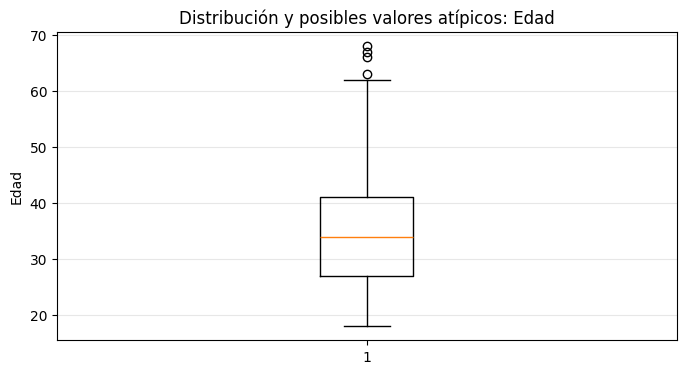

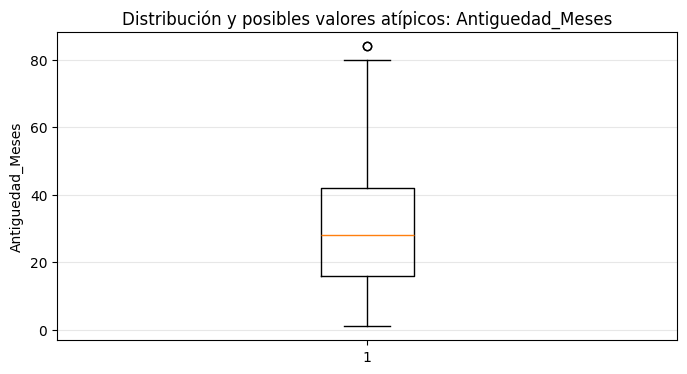

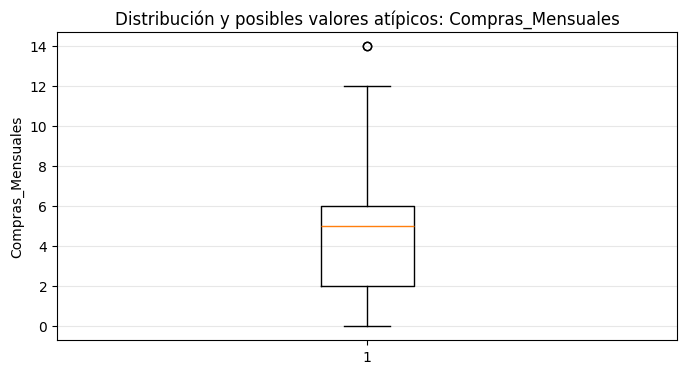

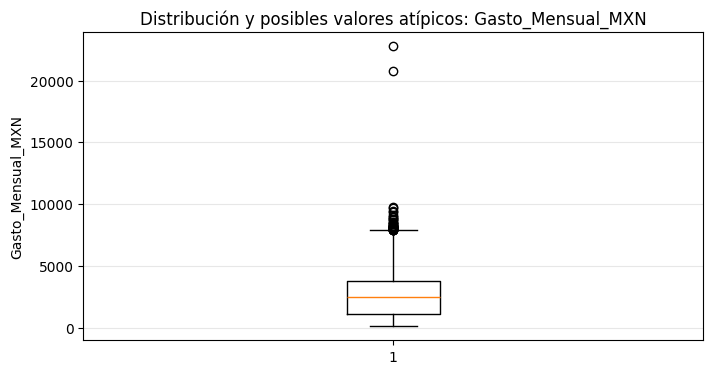

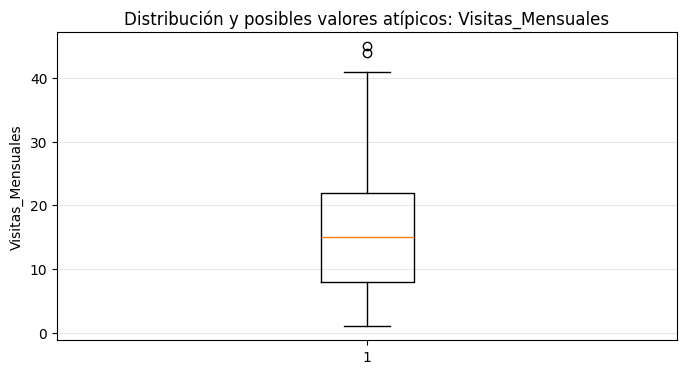

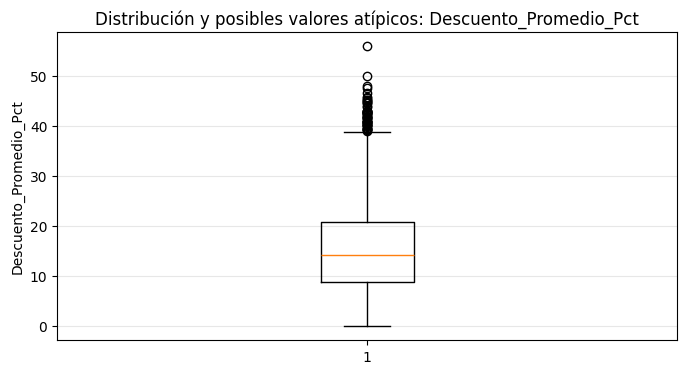

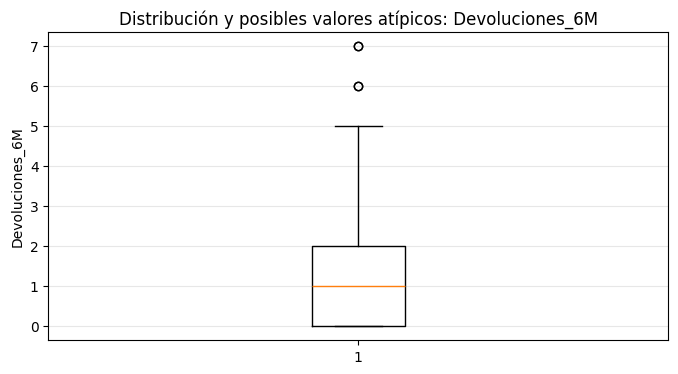

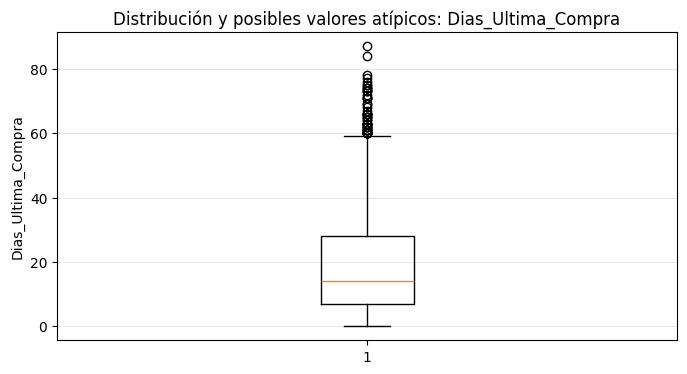

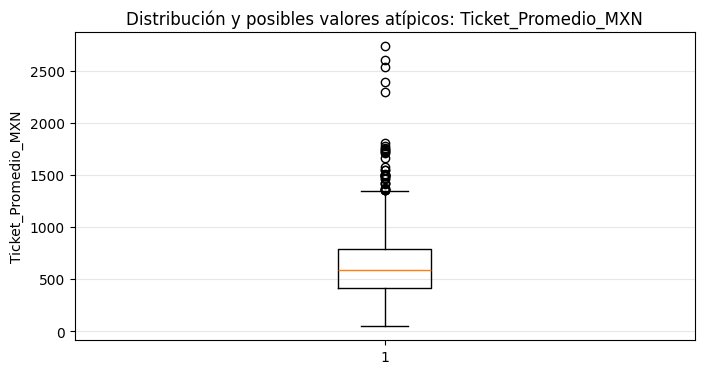

In [22]:
# Boxplots individuales para revisar valores atípicos

for columna in columnas_numericas:
    plt.figure(figsize=(8, 4))

    plt.boxplot(df_limpio[columna].dropna())

    plt.title(f"Distribución y posibles valores atípicos: {columna}")
    plt.ylabel(columna)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

In [23]:
# Detección de posibles valores atípicos mediante IQR

resumen_outliers = []

for columna in columnas_numericas:
    Q1 = df_limpio[columna].quantile(0.25)
    Q3 = df_limpio[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_limpio[
        (df_limpio[columna] < limite_inferior) |
        (df_limpio[columna] > limite_superior)
    ]

    resumen_outliers.append({
        'Variable': columna,
        'Q1': Q1,
        'Q3': Q3,
        'Limite inferior': limite_inferior,
        'Limite superior': limite_superior,
        'Posibles outliers': len(outliers),
        'Porcentaje (%)': round(len(outliers) / len(df_limpio) * 100, 2)
    })

resumen_outliers = pd.DataFrame(resumen_outliers)

resumen_outliers

,Variable,Q1,Q3,Limite inferior,Limite superior,Posibles outliers,Porcentaje (%)
0,Edad,27.0000,41.000,6.00000,62.00000,4,0.27
1,Antiguedad_Meses,16.0000,42.000,-23.00000,81.00000,2,0.13
2,Compras_Mensuales,2.0000,6.000,-4.00000,12.00000,2,0.13
3,Gasto_Mensual_MXN,1061.0050,3798.085,-3044.61500,7903.70500,37,2.47
4,Visitas_Mensuales,8.0000,22.000,-13.00000,43.00000,2,0.13
5,Descuento_Promedio_Pct,8.9000,20.900,-9.10000,38.90000,52,3.47
6,Devoluciones_6M,0.0000,2.000,-3.00000,5.00000,4,0.27
7,Dias_Ultima_Compra,7.0000,28.000,-24.50000,59.50000,59,3.93
8,Ticket_Promedio_MXN,419.4475,794.125,-142.56875,1356.14125,35,2.33


In [24]:
# Mostrar los valores atípicos detectados por variable

for columna in columnas_numericas:
    Q1 = df_limpio[columna].quantile(0.25)
    Q3 = df_limpio[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_limpio[
        (df_limpio[columna] < limite_inferior) |
        (df_limpio[columna] > limite_superior)
    ][['Cliente_ID', columna]]

    if len(outliers) > 0:
        print(f"\n{'='*60}")
        print(f"VARIABLE: {columna}")
        print(f"Límite inferior: {limite_inferior:.2f}")
        print(f"Límite superior: {limite_superior:.2f}")
        print(f"Cantidad de posibles outliers: {len(outliers)}")
        print(f"{'='*60}")
        print(outliers.to_string(index=False))


VARIABLE: Edad
Límite inferior: 6.00
Límite superior: 62.00
Cantidad de posibles outliers: 4
Cliente_ID  Edad
   CLI0291  67.0
   CLI0317  66.0
   CLI0627  68.0
   CLI0892  63.0

VARIABLE: Antiguedad_Meses
Límite inferior: -23.00
Límite superior: 81.00
Cantidad de posibles outliers: 2
Cliente_ID  Antiguedad_Meses
   CLI0619              84.0
   CLI0758              84.0

VARIABLE: Compras_Mensuales
Límite inferior: -4.00
Límite superior: 12.00
Cantidad de posibles outliers: 2
Cliente_ID  Compras_Mensuales
   CLI0630                 14
   CLI1199                 14

VARIABLE: Gasto_Mensual_MXN
Límite inferior: -3044.61
Límite superior: 7903.70
Cantidad de posibles outliers: 37
Cliente_ID  Gasto_Mensual_MXN
   CLI0025           8028.270
   CLI0055           8723.550
   CLI0094           9362.860
   CLI0154           9115.200
   CLI0197           8383.200
   CLI0200           8497.180
   CLI0294           8804.790
   CLI0360           8196.660
   CLI0412           8351.280
   CLI0421    

In [25]:
# Revisión de valores potencialmente inválidos

print("Edad menor a 18 o mayor a 100:")
print(df_limpio[(df_limpio['Edad'] < 18) | (df_limpio['Edad'] > 100)][
    ['Cliente_ID', 'Edad']
])

print("\nValores negativos:")
for columna in columnas_numericas:
    negativos = df_limpio[df_limpio[columna] < 0]

    if len(negativos) > 0:
        print(f"\n{columna}: {len(negativos)} valores negativos")
        print(negativos[['Cliente_ID', columna]].to_string(index=False))

Edad menor a 18 o mayor a 100:
Empty DataFrame
Columns: [Cliente_ID, Edad]
Index: []

Valores negativos:


In [26]:
print("Descuento promedio fuera del rango 0-100%:")
print(
    df_limpio[
        (df_limpio['Descuento_Promedio_Pct'] < 0) |
        (df_limpio['Descuento_Promedio_Pct'] > 100)
    ][['Cliente_ID', 'Descuento_Promedio_Pct']]
)

Descuento promedio fuera del rango 0-100%:
Empty DataFrame
Columns: [Cliente_ID, Descuento_Promedio_Pct]
Index: []


In [27]:
# Matriz de correlación

correlacion = df_limpio[columnas_numericas].corr()

correlacion.round(2)

,Edad,Antiguedad_Meses,Compras_Mensuales,Gasto_Mensual_MXN,Visitas_Mensuales,Descuento_Promedio_Pct,Devoluciones_6M,Dias_Ultima_Compra,Ticket_Promedio_MXN
Edad,1.00,0.36,0.42,0.43,0.31,-0.24,0.05,-0.30,0.16
Antiguedad_Meses,0.36,1.00,0.66,0.65,0.55,-0.35,0.14,-0.54,0.21
Compras_Mensuales,0.42,0.66,1.00,0.77,0.66,-0.37,0.21,-0.61,-0.05
Gasto_Mensual_MXN,0.43,0.65,0.77,1.00,0.62,-0.45,0.16,-0.58,0.44
Visitas_Mensuales,0.31,0.55,0.66,0.62,1.00,-0.13,0.25,-0.56,0.18
Descuento_Promedio_Pct,-0.24,-0.35,-0.37,-0.45,-0.13,1.00,0.11,0.22,-0.18
Devoluciones_6M,0.05,0.14,0.21,0.16,0.25,0.11,1.00,-0.21,-0.00
Dias_Ultima_Compra,-0.30,-0.54,-0.61,-0.58,-0.56,0.22,-0.21,1.00,-0.20
Ticket_Promedio_MXN,0.16,0.21,-0.05,0.44,0.18,-0.18,-0.00,-0.20,1.00


In [28]:
estadisticas = df_limpio[columnas_numericas].describe().T
estadisticas.round(2)

,count,mean,std,min,25%,50%,75%,max
Edad,1500.0,34.08,9.53,18.0,27.00,34.0,41.00,68.00
Antiguedad_Meses,1500.0,29.55,17.41,1.0,16.00,28.0,42.00,84.00
Compras_Mensuales,1500.0,4.66,2.74,0.0,2.00,5.0,6.00,14.00
Gasto_Mensual_MXN,1500.0,2959.33,2294.44,100.0,1061.01,2454.4,3798.08,22787.24
Visitas_Mensuales,1500.0,15.41,8.48,1.0,8.00,15.0,22.00,45.00
Descuento_Promedio_Pct,1500.0,15.97,9.76,0.0,8.90,14.3,20.90,55.90
Devoluciones_6M,1500.0,1.04,1.09,0.0,0.00,1.0,2.00,7.00
Dias_Ultima_Compra,1500.0,19.80,17.35,0.0,7.00,14.0,28.00,87.00
Ticket_Promedio_MXN,1500.0,633.85,306.78,50.0,419.45,587.1,794.12,2736.04


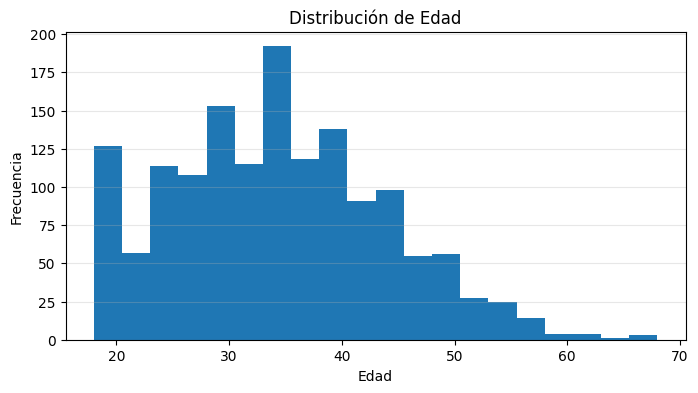

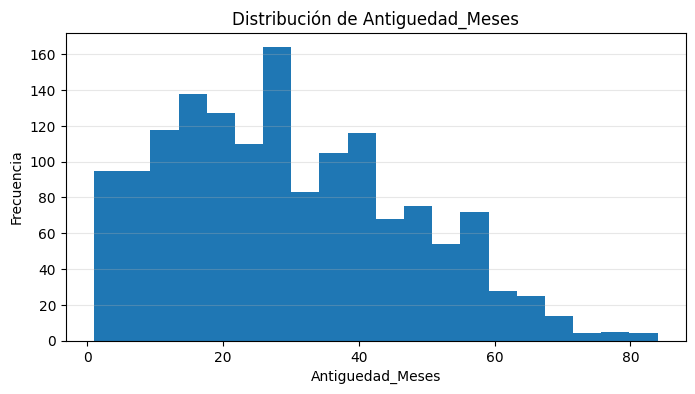

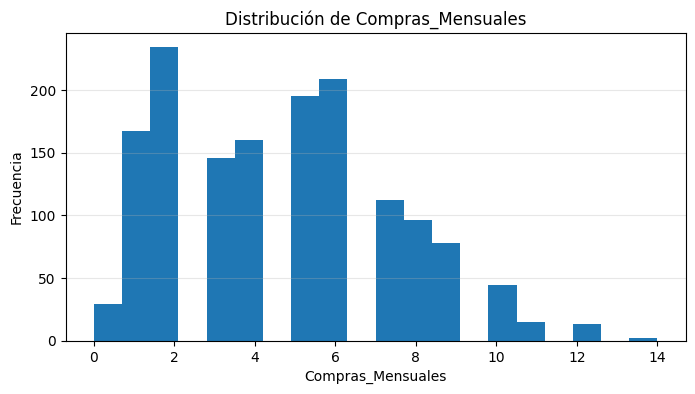

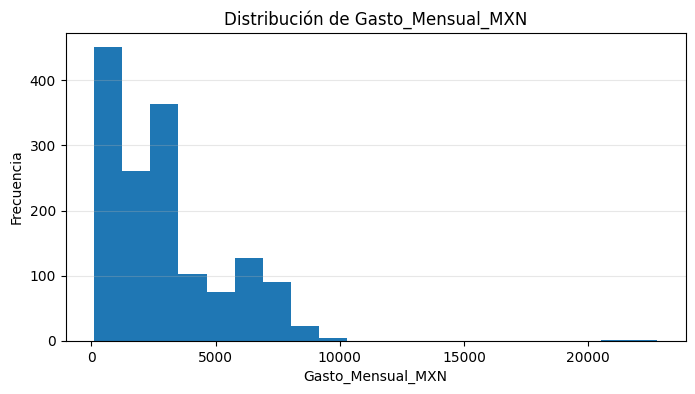

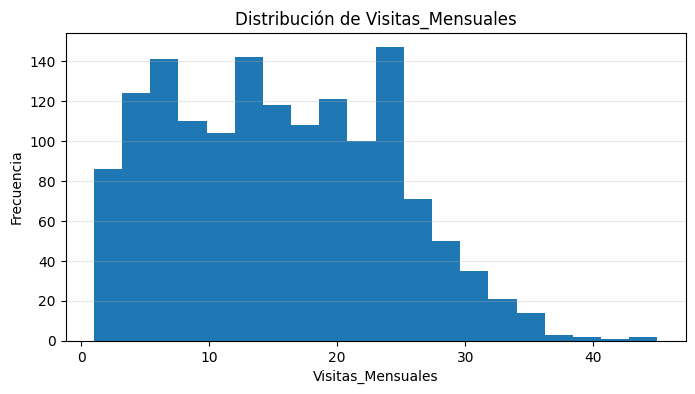

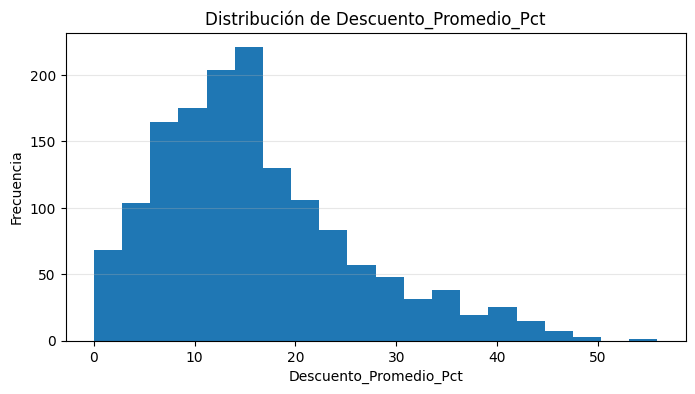

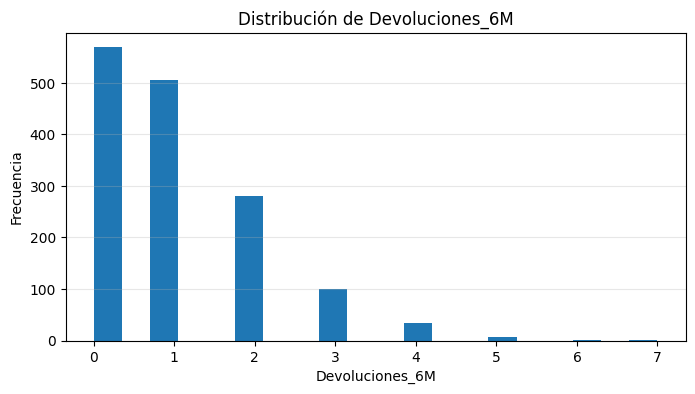

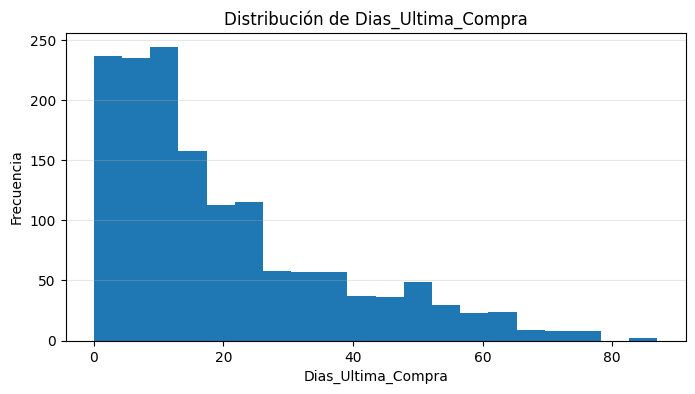

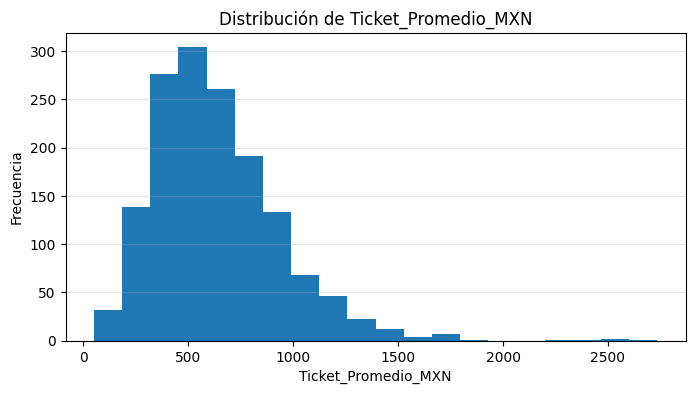

In [29]:
import matplotlib.pyplot as plt

columnas_graficas = [
    'Edad',
    'Antiguedad_Meses',
    'Compras_Mensuales',
    'Gasto_Mensual_MXN',
    'Visitas_Mensuales',
    'Descuento_Promedio_Pct',
    'Devoluciones_6M',
    'Dias_Ultima_Compra',
    'Ticket_Promedio_MXN'
]

for columna in columnas_graficas:
    plt.figure(figsize=(8, 4))
    plt.hist(df_limpio[columna], bins=20)
    plt.title(f'Distribución de {columna}')
    plt.xlabel(columna)
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

In [30]:
columnas_clustering = [
    'Edad',
    'Antiguedad_Meses',
    'Compras_Mensuales',
    'Gasto_Mensual_MXN',
    'Visitas_Mensuales',
    'Descuento_Promedio_Pct',
    'Devoluciones_6M',
    'Dias_Ultima_Compra',
    'Ticket_Promedio_MXN'
]

X = df_limpio[columnas_clustering].copy()

print("Variables utilizadas para el clustering:")
print(columnas_clustering)

print("\nDimensiones de X:")
print(X.shape)

Variables utilizadas para el clustering:
['Edad', 'Antiguedad_Meses', 'Compras_Mensuales', 'Gasto_Mensual_MXN', 'Visitas_Mensuales', 'Descuento_Promedio_Pct', 'Devoluciones_6M', 'Dias_Ultima_Compra', 'Ticket_Promedio_MXN']

Dimensiones de X:
(1500, 9)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_escalado = scaler.fit_transform(X)

X_escalado_df = pd.DataFrame(
    X_escalado,
    columns=columnas_clustering
)

X_escalado_df.head()

,Edad,Antiguedad_Meses,Compras_Mensuales,Gasto_Mensual_MXN,Visitas_Mensuales,Descuento_Promedio_Pct,Devoluciones_6M,Dias_Ultima_Compra,Ticket_Promedio_MXN
0,1.145988,0.141034,0.489903,0.621324,0.658945,-0.611924,-0.956791,0.242180,0.409475
1,-0.638604,0.026123,0.489903,-0.018517,1.248551,-0.037989,-0.956791,-1.026179,-0.700717
2,-0.218700,0.887955,-0.239481,0.055377,-0.402348,-0.171224,0.882013,-0.680263,0.398258
3,0.516132,0.083579,-0.968865,-1.028062,-0.402348,0.751171,-0.956791,2.317676,-0.924047
4,0.096228,-0.720798,-0.968865,-0.843215,-0.991955,-0.642670,-0.956791,2.029412,-0.508365


In [32]:
X_escalado_df.agg(['mean', 'std']).round(2)

,Edad,Antiguedad_Meses,Compras_Mensuales,Gasto_Mensual_MXN,Visitas_Mensuales,Descuento_Promedio_Pct,Devoluciones_6M,Dias_Ultima_Compra,Ticket_Promedio_MXN
mean,-0.0,0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

inercia = []
silhouette = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    etiquetas = kmeans.fit_predict(X_escalado)

    inercia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_escalado, etiquetas))

resultados_k = pd.DataFrame({
    'K': list(K_range),
    'Inercia': inercia,
    'Silhouette': silhouette
})

resultados_k.round(4)

,K,Inercia,Silhouette
0,2,9275.9369,0.2704
1,3,7537.6916,0.2402
2,4,6721.0844,0.2335
3,5,6253.0052,0.2237
4,6,5923.2445,0.2012
5,7,5620.3268,0.1719
6,8,5362.9076,0.1625
7,9,5169.1909,0.1493
8,10,4981.1102,0.1511


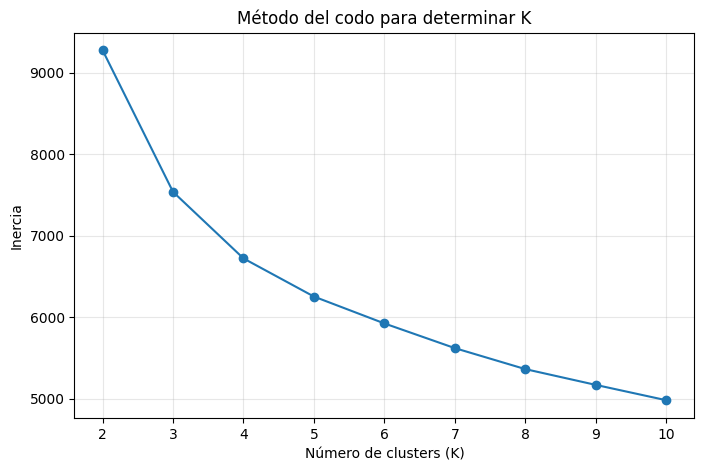

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inercia, marker='o')
plt.title('Método del codo para determinar K')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.xticks(list(K_range))
plt.grid(alpha=0.3)
plt.show()

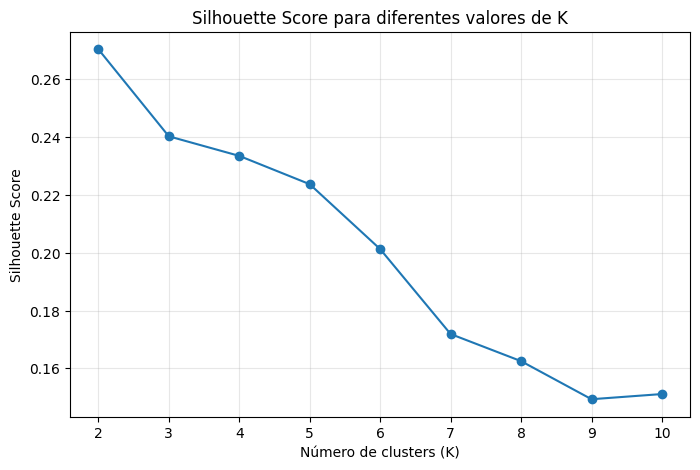

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(list(K_range), silhouette, marker='o')
plt.title('Silhouette Score para diferentes valores de K')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(K_range))
plt.grid(alpha=0.3)
plt.show()

#Entrenamiento del modelo

In [36]:
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df_limpio['Cluster'] = kmeans_final.fit_predict(X_escalado)

print("Clientes por cluster:")
print(df_limpio['Cluster'].value_counts().sort_index())

Clientes por cluster:
Cluster
0    757
1    743
Name: count, dtype: int64


In [37]:
perfil_clusters = df_limpio.groupby('Cluster')[columnas_clustering].mean()

perfil_clusters.round(2)

,Edad,Antiguedad_Meses,Compras_Mensuales,Gasto_Mensual_MXN,Visitas_Mensuales,Descuento_Promedio_Pct,Devoluciones_6M,Dias_Ultima_Compra,Ticket_Promedio_MXN
Cluster,,,,,,,,,
0,38.61,41.69,6.62,4544.11,20.49,11.11,1.27,9.4,699.80
1,29.47,17.17,2.65,1344.70,10.24,20.92,0.80,30.4,566.67


In [38]:
perfil_clusters = df_limpio.groupby('Cluster')[columnas_clustering].mean()

perfil_clusters.round(2)

,Edad,Antiguedad_Meses,Compras_Mensuales,Gasto_Mensual_MXN,Visitas_Mensuales,Descuento_Promedio_Pct,Devoluciones_6M,Dias_Ultima_Compra,Ticket_Promedio_MXN
Cluster,,,,,,,,,
0,38.61,41.69,6.62,4544.11,20.49,11.11,1.27,9.4,699.80
1,29.47,17.17,2.65,1344.70,10.24,20.92,0.80,30.4,566.67


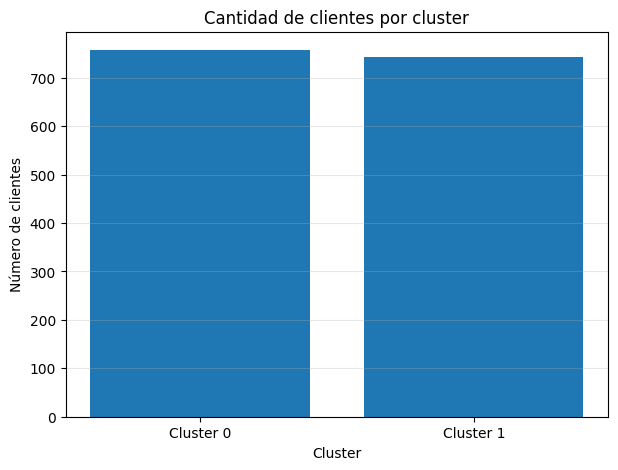

In [39]:
import matplotlib.pyplot as plt

conteo_clusters = df_limpio['Cluster'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ['Cluster 0', 'Cluster 1'],
    conteo_clusters.values
)

plt.title('Cantidad de clientes por cluster')
plt.xlabel('Cluster')
plt.ylabel('Número de clientes')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Aplicar PCA para reducir las 9 variables a 2 componentes
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_escalado)

# Crear DataFrame con los componentes
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

# Agregar el cluster correspondiente
pca_df['Cluster'] = df_limpio['Cluster'].values

# Varianza explicada
print("Varianza explicada por PC1:", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("Varianza explicada por PC2:", round(pca.explained_variance_ratio_[1] * 100, 2), "%")
print("Varianza explicada acumulada:", round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

Varianza explicada por PC1: 44.93 %
Varianza explicada por PC2: 13.95 %
Varianza explicada acumulada: 58.88 %


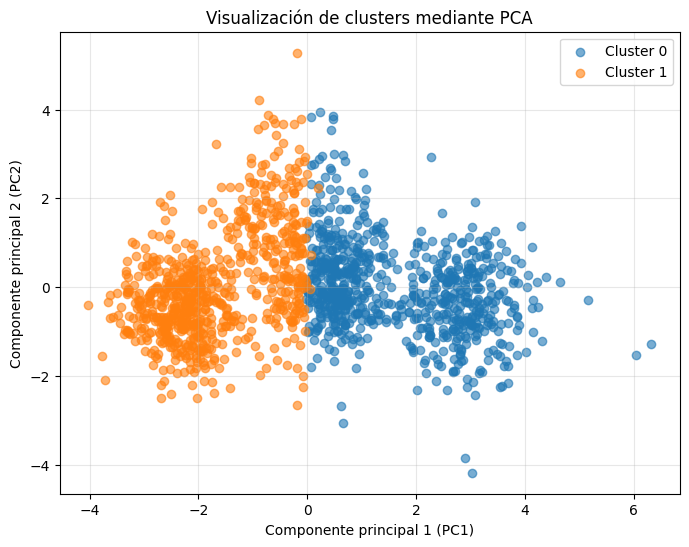

In [41]:
plt.figure(figsize=(8, 6))

for cluster in sorted(pca_df['Cluster'].unique()):
    datos = pca_df[pca_df['Cluster'] == cluster]

    plt.scatter(
        datos['PC1'],
        datos['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.title('Visualización de clusters mediante PCA')
plt.xlabel('Componente principal 1 (PC1)')
plt.ylabel('Componente principal 2 (PC2)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [42]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

dbscan = DBSCAN(
    eps=1.2,
    min_samples=10
)

clusters_dbscan = dbscan.fit_predict(X_escalado)

df_limpio['Cluster_DBSCAN'] = clusters_dbscan

print("Clusters encontrados por DBSCAN:")
print(df_limpio['Cluster_DBSCAN'].value_counts().sort_index())

Clusters encontrados por DBSCAN:
Cluster_DBSCAN
-1    770
 0    631
 1     93
 2      6
Name: count, dtype: int64


In [43]:
n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)

n_ruido = np.sum(clusters_dbscan == -1)

print("Número de clusters:", n_clusters_dbscan)
print("Puntos considerados ruido:", n_ruido)

Número de clusters: 3
Puntos considerados ruido: 770


In [44]:
if n_clusters_dbscan > 1:
    datos_silhouette = X_escalado[clusters_dbscan != -1]
    etiquetas_silhouette = clusters_dbscan[clusters_dbscan != -1]

    silhouette_dbscan = silhouette_score(
        datos_silhouette,
        etiquetas_silhouette
    )

    print("Silhouette Score de DBSCAN:", round(silhouette_dbscan, 4))
else:
    print("No es posible calcular Silhouette Score con un solo cluster.")

Silhouette Score de DBSCAN: 0.2543


#9. Comparación con otro algoritmo

In [45]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

dbscan = DBSCAN(
    eps=1.2,
    min_samples=10
)

clusters_dbscan = dbscan.fit_predict(X_escalado)

df_limpio['Cluster_DBSCAN'] = clusters_dbscan

print("Clusters encontrados por DBSCAN:")
print(df_limpio['Cluster_DBSCAN'].value_counts().sort_index())

Clusters encontrados por DBSCAN:
Cluster_DBSCAN
-1    770
 0    631
 1     93
 2      6
Name: count, dtype: int64


In [46]:
n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)

n_ruido = np.sum(clusters_dbscan == -1)

print("Número de clusters:", n_clusters_dbscan)
print("Puntos considerados ruido:", n_ruido)

Número de clusters: 3
Puntos considerados ruido: 770


In [47]:
if n_clusters_dbscan > 1:
    datos_silhouette = X_escalado[clusters_dbscan != -1]
    etiquetas_silhouette = clusters_dbscan[clusters_dbscan != -1]

    silhouette_dbscan = silhouette_score(
        datos_silhouette,
        etiquetas_silhouette
    )

    print("Silhouette Score de DBSCAN:", round(silhouette_dbscan, 4))
else:
    print("No es posible calcular Silhouette Score con un solo cluster.")

Silhouette Score de DBSCAN: 0.2543
